# Figure 6. CF metagenome analysis

In [30]:
### Create samplesheet from downloaded CF metagenomes
import polars as pl
import glob
import os

cf_metag_samplesheet = pl.read_csv('cf_metagenome_samplesheet.csv')
lipuma_samplesheet = pl.read_csv('lipuma_samplesheet.csv').drop('coassembly_group')

combined_samplesheet = pl.concat([cf_metag_samplesheet, lipuma_samplesheet], how='vertical')

base = "/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/results/uhvdb/assemble/"

def check_path(path):
    """Helper to return path if it exists, else None."""
    return path if path and os.path.exists(path) else None

# 1. Construct the path strings using Polars logic
# 2. Use map_elements to check the filesystem
finalized_df = (
    combined_samplesheet.with_columns([
        # Generate the 'base' path parts
        (pl.lit(base) + pl.col('bioproject') + '/' + pl.col('group') + '/' + pl.col('sample')).alias('_base_path'),
        (pl.col('group')).alias('_acc')
    ])
    .with_columns([
        # Logic for fastq_1: Check standard first, then _R1
        pl.struct([
            (pl.col('_base_path') + '/readdownload/' + pl.col('_acc') + '.deacon.fastq.gz').alias('a'),
            (pl.col('_base_path') + '/readdownload/' + pl.col('_acc') + '_R1.deacon.fastq.gz').alias('b'),
            (pl.col('_base_path') + '/readpreprocessing/' + pl.col('_acc') + '_1.deacon.fastq.gz').alias('c')
        ]).map_elements(
            lambda s: s['a'] if os.path.exists(s['a']) else (s['b'] if os.path.exists(s['b']) else (s['c'] if os.path.exists(s['c']) else None)),
            return_dtype=pl.String
        ).alias('fastq_1'),

        # Logic for fastq_2: Check standard first, then _R2
        pl.struct([
            (pl.col('_base_path') + '/readdownload/' + pl.col('_acc') + '_R2.deacon.fastq.gz').alias('a'),
            (pl.col('_base_path') + '/readpreprocessing/' + pl.col('_acc') + '_2.deacon.fastq.gz').alias('b')
        ]).map_elements(
            lambda s: s['a'] if os.path.exists(s['a']) else (s['b'] if os.path.exists(s['b']) else None),
            return_dtype=pl.String
        ).alias('fastq_2'),

        # Logic for fna
        (pl.col('_base_path') + '/megahit/' + pl.col('sample') + '.contigs.fa.gz')
        .map_elements(check_path, return_dtype=pl.String)
        .alias('fna'),
    ])
    .drop(['_base_path', '_acc'])
)

finalized_df.write_csv('finalized_cf_metagenome_samplesheet.csv')

In [ ]:
%%bash
### Run samples through UHVDB analyze workflows
mkdir -p cf_metag_results
cd cf_metag_results

nextflow run /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/toolkit \
    -profile uw_hyak \
    -w /gscratch/scrubbed/carsonjm/2026.04.08-cf_metag \
    --input /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_6/finalized_cf_metagenome_samplesheet.csv \
    --db_dir /gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/toolkit/databases \
    --checkv_db /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_s16/uhvdb_cf_results/uhvdb_2026-04-03/checkv_db/checkv_db_2026-04-03 \
    --output_dir /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_6/cf_metag_results \
    --uhvdb_dir /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_s16/uhvdb_cf_results/uhvdb_2026-04-03 \
    --hyak_partition="pedslabs" \
    --hyak_queue="compute-hugemem" \
    --new_release_id="2026-04-08" \
    --run_assemble=true \
    --run_reference_analyze=true \
    --bacterial_sylph_db='http://faust.compbio.cs.cmu.edu/sylph-stuff/v0.3-c1000-gtdb-r214.syldb' \
    --run_assembly_analyze=true

In [3]:
import glob
import os
import polars as pl
from polars.exceptions import NoDataError

sylph_lst = []

for dir in glob.glob('/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/results/uhvdb/assemble/*/*/*/readdownload/'):
    # check if sylph results exist
    if not os.path.isfile(f'{dir}/sylph_uhvdb_r202510_globdb_r226.profile.tsv'):
        continue
    # get sample name
    sample_name = dir.split('/')[-3]
    bioproject = dir.split('/')[-5]
    # parse log to count number of bp after deacon
    with open(f'{dir}/.command.log', 'r') as log:
        for line in log:
            if line.startswith('Retained '):
                num_bp = int(line.split()[4].split('/')[0])

    # parse sylph results to count number of genomes, bac, and viruses per bp
    try:
        df = pl.read_csv((dir + 'sylph_uhvdb_r202510_globdb_r226.profile.tsv'), separator='\t', ignore_errors=True)

        if df.height == 0:
            raise NoDataError

        sylph_lst.append(
            df.with_columns([
                pl.lit(num_bp).cast(pl.Int64).alias('num_bp'),
                pl.lit(sample_name).alias('sample_id'),
                pl.lit(bioproject).alias('bioproject'),
                pl.col('Contig_name').str.split(' ').list[0].alias('contig_id')
            ])
            [['num_bp', 'sample_id', 'bioproject', 'contig_id', 'Genome_file', 'Taxonomic_abundance', 'Sequence_abundance', 'Adjusted_ANI', 'True_cov']]
        )
    except NoDataError:
        df = pl.DataFrame(
            {
                'num_bp': [num_bp],
                'sample_id': [sample_name],
                'bioproject': [bioproject],
                'contig_id': [None],
                'Genome_file': [None],
                'Taxonomic_abundance': [0.0],
                'Sequence_abundance': [0.0],
                'Adjusted_ANI': [0.0],
                'True_cov': [0.0]
            }
        )

        sylph_lst.append(df)

sylph_df = pl.concat(sylph_lst)

# 2. CoverM

In [4]:
# import glob

# # create contained genomes files
# for file in glob.glob('/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/results/uhvdb/assemble/*/*/*/readdownload/sylph_uhvdb_r202510_globdb_r226.profile.tsv'):
#     with open(file + '.contained_genomes.txt', 'w') as out_f:
#         for line in open(file):
#             if line.startswith('Sample_file'):
#                 continue
#             contig_id = line.strip().split('\t')[-1].split()[0]
#             out_f.write(contig_id + '\n')
#     out_f.close()

# # create sylph profile config file
# !ls /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/results/uhvdb/assemble/*/ > sylph_profile_config.txt

# # create update sylph profile config
# id = 0

# with open('sylph_profile_config.txt', 'r') as f_in:
#     with open('sylph_profile_config_2.txt', 'w') as f_out:
#         for line in f_in:
#             if 'prj' in line:
#                 line = line.strip().replace(':', '')
#                 f_out.write(f'{id}\t{line}\n')
#                 id += 1
#             else:
#                 continue

# f_in.close()
# f_out.close()

In [5]:
%%bash
# # align reads to contained viral genomes
# sbatch coverm.sh

In [6]:
import glob
import os
import math
import polars as pl
from polars.exceptions import NoDataError

coverm_lst = []

for dir in glob.glob('/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/results/uhvdb/assemble/*/*/*/readdownload/'):
    # check if coverm results exist
    if not os.path.isfile(f'{dir}/sylph_uhvdb_r202510_globdb_r226.profile.tsv.coverm.tsv'):
        continue
    # get sample name
    sample_name = dir.split('/')[-3]
    bioproject = dir.split('/')[-5]
    # parse log to count number of bp after deacon
    with open(f'{dir}/.command.log', 'r') as log:
        for line in log:
            if line.startswith('Retained '):
                num_bp = int(line.split()[4].split('/')[0])

    # parse coverm results to count number of genomes, bac, and viruses per bp
    try:
        df = (
            pl.read_csv((dir + 'sylph_uhvdb_r202510_globdb_r226.profile.tsv.coverm.tsv'),
                separator='\t', ignore_errors=True, new_columns=['contig_id', 'trimmed_mean', 'mean', 'covered_bases', 'length'])
                .with_columns([
                    (pl.col('covered_bases') / pl.col('length')).alias('breadth'),
                ])
                .with_columns([
                    (1 - math.e**(-0.833 * pl.col('mean'))).alias('expected_breadth'),
                ])
                .with_columns([
                    (pl.col('breadth')/pl.col('expected_breadth')).alias('breadth_ratio'),
                ])
        )

        if df.height == 0:
            raise NoDataError

        coverm_lst.append(
            df.with_columns([
                pl.lit(num_bp).cast(pl.Int64).alias('num_bp'),
                pl.lit(sample_name).alias('sample_id'),
                pl.lit(bioproject).alias('bioproject')
            ])
            [['num_bp', 'sample_id', 'bioproject', 'contig_id', 'trimmed_mean', 'mean', 'breadth', 'breadth_ratio']]
        )
    except NoDataError:
        df = pl.DataFrame(
            {
                'num_bp': [num_bp],
                'sample_id': [sample_name],
                'bioproject': [bioproject],
                'contig_id': [None],
                'trimmed_mean': [0.0],
                'mean': [0.0],
                'breadth': [0.0],
                'breadth_ratio': [0.0]
            }
        )

        coverm_lst.append(df)

coverm_df = pl.concat(coverm_lst, how='vertical_relaxed')
print(coverm_df.height)

64816


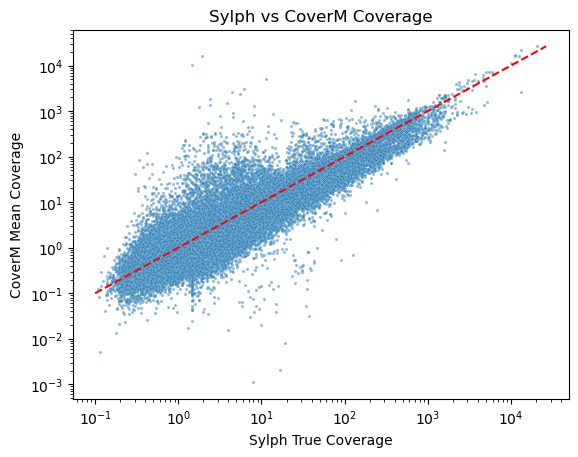

In [7]:
# plot sylph vs coverm coverage
sylph_w_coverm = (
    sylph_df
        .join(
            coverm_df,
            on=['sample_id', 'contig_id', 'bioproject', 'num_bp'],
            how='inner'
        )
)
import seaborn as sns
import matplotlib.pyplot as plt
# prepare data for plotting
sns.scatterplot(data=sylph_w_coverm, x='True_cov', y='trimmed_mean', s=5, alpha=0.5)
plt.yscale('log')
plt.xscale('log')
# plot diagonal
max_cov = max(sylph_w_coverm['True_cov'].max(), sylph_w_coverm['trimmed_mean'].max())
plt.plot([0.1, max_cov], [0.1, max_cov], color='red', linestyle='--')
plt.xlabel('Sylph True Coverage')
plt.ylabel('CoverM Mean Coverage')
plt.title('Sylph vs CoverM Coverage')
plt.show()

In [8]:
%%bash
# #count the number of mvirs hits in CF metagenomes
# cat /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/results/uhvdb/analyze/prj*/*/*_cf/strobealign/*_cf.mvirs.fasta | grep -c "^>"
# 1,010 mvirs genomes

# # count the number of TRs in CF metagenomes
# zcat /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/results/uhvdb/mine/prj*/*/*_cf/checkv2/*_cf_quality_summary.tsv.gz | grep -c "TR ("
# 904 DTR genomes

# Propagate 1920 LC, 752 HC

In [9]:
%%bash
# echo "/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/uhvdb_final_files/r2025_10/uhvdb_votu_reps.fna.gz" > ref_kdb.txt

# # build kmer-db database for reference
# kmer-db \
#     build \
#     -k 25 \
#     -f 0.2 \
#     -t 32 \
#     -multisample-fasta \
#     ref_kdb.txt \
#     ref.kdb

# echo "/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_6/combined_cf_metagenome_viruses.fna.gz" > query_kdb.txt

# # compare query to reference
# kmer-db \
#     new2all \
#     -sparse \
#     -min num-kmers:20 \
#     -min ani-shorter:0.0 \
#     -t 32 \
#     -multisample-fasta \
#     ref.kdb \
#     query_kdb.txt \
#     query_v_ref.csv

# # convert kmer-db output to LZ-ANI filter format
# kmer-db \
#     distance \
#     ani-shorter \
#     -sparse \
#     -min 0.0 \
#     -t 32 \
#     query_v_ref.csv \
#     query_v_ref.dist.csv

# /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb/bin/kmerdb_new2all_to_lzani.py \
#     -i query_v_ref.dist.csv \
#     -o cf_metagenome_viruses_v_uhvdb_r2025_10.vclust_prefilter.txt

# zcat "/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/uhvdb_final_files/r2025_10/uhvdb_votu_reps.fna.gz" > cf_metagenome_viruses_v_uhvdb_r2025_10.ref_query_combined.fna
# zcat /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_6/combined_cf_metagenome_viruses.fna.gz >> cf_metagenome_viruses_v_uhvdb_r2025_10.ref_query_combined.fna

# # align sequences with LZ-ANI
# lz-ani \
#     all2all \
#     --in-fasta cf_metagenome_viruses_v_uhvdb_r2025_10.ref_query_combined.fna \
#     -o cf_metagenome_viruses_v_uhvdb_r2025_10.vclust_ani.tsv \
#     --out-format query,reference,gani,tani,ani,qcov,rcov \
#     -t 32 \
#     --multisample-fasta true \
#     --out-type tsv \
#     --out-filter ani 0.0 \
#     --flt-kmerdb cf_metagenome_viruses_v_uhvdb_r2025_10.vclust_prefilter.txt 0.0

# gzip cf_metagenome_viruses_v_uhvdb_r2025_10.ref_query_combined.fna

In [10]:
# load unenriched vs uhvdb blast results
cf_viruses_v_uhvdb = (
    pl.read_csv('/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_6/cf_metagenome_viruses_v_uhvdb_r2025_10.vclust_ani.tsv', separator='\t')
        .with_columns([
            pl.col('query').str.split('_k').list[0].alias('sample_id')
        ])
        .sort('tani', descending=True)
        .group_by('query', maintain_order=True)
        .head(100)
)

top_hit_per_sample = (
    coverm_df
        .join(cf_viruses_v_uhvdb, left_on=['contig_id', 'sample_id'], right_on=['reference', 'sample_id'], how='inner')
        .sort('tani', descending=True)
        .group_by(['query', 'sample_id'], maintain_order=True)
        .first()
)

In [11]:
# load bacphlip results for UHVDB
bacphlip_lst = []
for file in glob.glob('/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_4/uhvdb_*_chunks/*.fna.bacphlip'):
    df = (
        pl.read_csv(file, separator='\t', null_values=['NA'], new_columns=['contig_id', 'virulent', 'temperate'])
    )
    bacphlip_lst.append(df)

bacphlip_df = (
    pl.concat(bacphlip_lst)
        .with_columns([
            pl.when(pl.col('contig_id').str.contains('provirus')).then(pl.lit(0.0)).otherwise(pl.col('virulent')).alias('virulent')
        ])
)

# load uhvdb votu info
uhvdb_info = (
    pl.read_csv('/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/uhvdb_cf_supplement/r2025_10_uhvdb_vclust_votu_cluster_info_final.tsv', separator='\t')
        .filter(pl.col('contig_id') == pl.col('votu_rep'))
        .unique('votu_rep')
)

# load checkv results for cf viruses
checkv_lst = []
for file in glob.glob('/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/results/uhvdb/mine/prj*/*/*_cf/checkv2/*_cf_quality_summary.tsv.gz'):
    df = (
        pl.read_csv(file, separator='\t', null_values=['NA'])
            [['contig_id', 'provirus', 'completeness', 'host_genes', 'viral_genes', 'completeness_method']]
    )
    checkv_lst.append(df)

checkv_df = (
    pl.concat(checkv_lst, how='vertical_relaxed')
)

# load mvirs results for cf viruses
# # identify mvirs active cf viruses
# !cat /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/results/uhvdb/analyze/prj*/*/*_cf/strobealign/*_cf.mvirs.fasta | \
#     grep "^>" > cf_mvirs_contig_ids.txt

mvirs_contigs = (
    pl.read_csv('cf_mvirs_contig_ids.txt', separator=' ', has_header=False, new_columns=['mvirs_id'])
        .with_columns([
            pl.col('mvirs_id').str.replace('>', '').str.split(':').list[0].alias('contig_id_no_prophage'),
            pl.col('mvirs_id').str.split('OPRs=').list[1].str.split('-').list[0].cast(pl.Int64).alias('num_oprs'),
            pl.col('mvirs_id').str.split('HSs=').list[1].str.split('-').list[0].cast(pl.Int64).alias('num_clipped'),
        ])
        .with_columns([
            pl.col('contig_id_no_prophage').str.split('_k').list[0].alias('sample_id')
        ])
)


# load propagate results for cf viruses
propagate_lst = []
for file in glob.glob('/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/results/uhvdb/analyze/prj*/*/*/propagate/*.propagate.tsv'):
    df = (
        pl.read_csv(file, separator='\t', null_values=['NA'], raise_if_empty=False)
    )
    if df.height > 0:
        df = (
            df
            .with_columns([
                    pl.col('prophage').cast(pl.String),
                    pl.col('host').cast(pl.String),
                    pl.col('prophage_len').cast(pl.Int64),
                    pl.col('CohenD').cast(pl.Float64),
                    pl.col('prophage-host_ratio').cast(pl.Float64),
                    pl.col('prophage').str.split('_k').list[0].alias('sample_id')
                ])
            [['prophage', 'prophage_len', 'host', 'CohenD', 'prophage-host_ratio', 'sample_id']]
        )
        propagate_lst.append(df)
    else:
        continue

propagate_df = (
    pl.concat(propagate_lst)
)


# combine all data together
activity_data = (
    sylph_w_coverm
        .join(uhvdb_info, on='contig_id', how='left')
        .join(bacphlip_df, on='contig_id', how='left')
        .join(top_hit_per_sample, left_on=['contig_id', 'sample_id'], right_on=['contig_id', 'sample_id'], how='left')
        .with_columns([
            pl.col('query').str.split('|provirus').list[0].alias('contig_id_no_prophage')
        ])
        .join(propagate_df, left_on=['query', 'sample_id'], right_on=['prophage', 'sample_id'], how='left')
        .join(checkv_df, left_on='query', right_on='contig_id', how='left')
        .join(mvirs_contigs, on=['contig_id_no_prophage', 'sample_id'], how='left')
        .with_columns([
            # breadth of coverage as an indicator that a virus is not fragmented
            pl.when((pl.col('breadth') >= 0.8) | (pl.col('breadth_ratio') >= 0.9)).then(pl.lit(1.0))
                .otherwise(pl.lit(0.0)).alias('breadth_score'),
            # reference evidence of activity
            pl.when((pl.col('completeness_method').str.contains('TR')) & (pl.col('breadth') >= 0.95)).then(pl.lit(3.0))
                .when(pl.col('completeness_method').str.contains('DTR')).then(pl.lit(1.0))
                .otherwise(pl.lit(0.0)).alias('ref_dtr_score'),
            pl.when((pl.col('virulent') >= 0.95) & ((pl.col('breadth') >= 0.9) | (pl.col('breadth_ratio') >= 0.95))).then(pl.lit(3.0))
                .when((pl.col('virulent') >= 0.95)).then(pl.lit(1.0))
                .otherwise(pl.lit(0.0)).alias('ref_virulent_score'),
            # complete genome activity evidence
            pl.when((pl.col('completeness_method_right').str.contains('TR'))).then(pl.lit(3.0))
                .otherwise(pl.lit(0.0)).alias('dtr_score'),
            pl.when((pl.col('num_oprs') + pl.col('num_clipped')) >= 5).then(pl.lit(3.0))
                .otherwise(pl.lit(0.0)).alias('mvirs_score'),
            # fragment evidence of activity
            pl.when((pl.col('CohenD') >= 1.5)).then(pl.lit(3.0))
                .when((pl.col('CohenD') >= 0.7)).then(pl.lit(1.0))
                .otherwise(pl.lit(0.0)).alias('propagate_score'),
        ])
        .group_by(['contig_id', 'sample_id', 'bioproject', 'num_bp'])
        .agg([
            pl.col('breadth_score').max().alias('breadth_score'),
            pl.col('ref_dtr_score').max().alias('ref_dtr_score'),
            pl.col('ref_virulent_score').max().alias('ref_virulent_score'),
            pl.col('trimmed_mean').first().alias('trimmed_mean'),
            pl.col('mean').first().alias('mean'),
            pl.col('breadth').first().alias('breadth'),
            pl.col('breadth_ratio').first().alias('breadth_ratio'),
            pl.col('True_cov').first().alias('True_cov_virus'),
            pl.col('completeness_method').first().alias('completeness_method'),
            pl.col('virulent').first().alias('virulent'),
            pl.col('dtr_score').max().alias('dtr_score'),
            pl.col('num_oprs').max().alias('num_oprs'),
            pl.col('num_clipped').max().alias('num_clipped'),
            pl.col('CohenD').max().alias('CohenD'),
            pl.col('prophage-host_ratio').max().alias('prophage-host_ratio'),
            pl.col('mvirs_score').max().alias('mvirs_score'),
            pl.col('propagate_score').max().alias('propagate_score'),
        ])
        .with_columns([
            (
                pl.col('breadth_score') +
                pl.col('ref_dtr_score') +
                pl.col('ref_virulent_score') +
                pl.col('dtr_score') +
                pl.col('mvirs_score') +
                pl.col('propagate_score')
            ).alias('activity_score')
        ])
        .with_columns([
            (
                pl.col('breadth_score') +
                pl.col('ref_dtr_score') +
                pl.col('ref_virulent_score')
            ).alias('reference_activity_score')
        ])
)
print(activity_data.height)

ValueError: cannot concat empty list

In [ ]:
activity_data.write_csv('cf_metagenome_virus_activity_data.tsv', separator='\t')

In [12]:

import polars as pl

activity_data = pl.read_csv('cf_metagenome_virus_activity_data.tsv', separator='\t')

(
    activity_data
        .with_columns([
            (pl.col('breadth_score') > 0).sum().alias('num_breadth_score'),
            (pl.col('ref_dtr_score') > 0).sum().alias('num_ref_dtr_score'),
            (pl.col('ref_virulent_score') > 0).sum().alias('num_ref_virulent_score'),
            (pl.col('dtr_score') > 0).sum().alias('num_dtr_score'),
            (pl.col('mvirs_score') > 0).sum().alias('num_mvirs_score'),
            (pl.col('propagate_score') > 0).sum().alias('num_propagate_score')
        ])
        [['num_breadth_score', 'num_ref_dtr_score', 'num_ref_virulent_score', 'num_dtr_score', 'num_mvirs_score', 'num_propagate_score']]
        .head(1)
)

num_breadth_score,num_ref_dtr_score,num_ref_virulent_score,num_dtr_score,num_mvirs_score,num_propagate_score
u32,u32,u32,u32,u32,u32
22943,8182,4848,879,886,915


In [13]:
### determine prevalence of active cf viruses
cf_sample_set = set(activity_data['sample_id'])
print("Number of CF samples analyzed:", len(cf_sample_set))

prevalence = (
    activity_data
        .filter(pl.col('breadth_ratio') >= 0.6)
        .group_by(['contig_id'])
        .agg([
            (pl.len().alias('num_samples_detected')*100/len(cf_sample_set)).alias('prevalence'),
            pl.col('activity_score').max().alias('activity_score')
        ])
        .with_columns([
            pl.when(pl.col('activity_score') >= 3).then(pl.lit('High-confidence'))
                .when((pl.col('activity_score') > 0) & (pl.col('activity_score') < 3)).then(pl.lit('Low-confidence'))
                .otherwise(pl.lit('Unknown')).alias('activity_level')
        ])
)

prevalence.filter(pl.col('prevalence') >= 10).write_csv('high_prev_cf_viruses.tsv', separator='\t')

Number of CF samples analyzed: 1789


In [14]:
prevalence.filter(pl.col('prevalence') >= 10)

contig_id,prevalence,activity_score,activity_level
str,f64,f64,str
"""ERZ21615859.50|provirus_3_5284…",12.073784,3.0,"""High-confidence"""
"""SAMN16578693.contig00006|provi…",13.750699,5.0,"""High-confidence"""
"""SAMEA110349439.contig00009|pro…",10.229178,1.0,"""Low-confidence"""
"""ERZ21615758.302""",11.794298,1.0,"""Low-confidence"""
"""SAMEA10741205_k141_41777""",17.719396,1.0,"""Low-confidence"""
"""SAMN40993948_SRR28721147_cf_k2…",11.682504,4.0,"""High-confidence"""


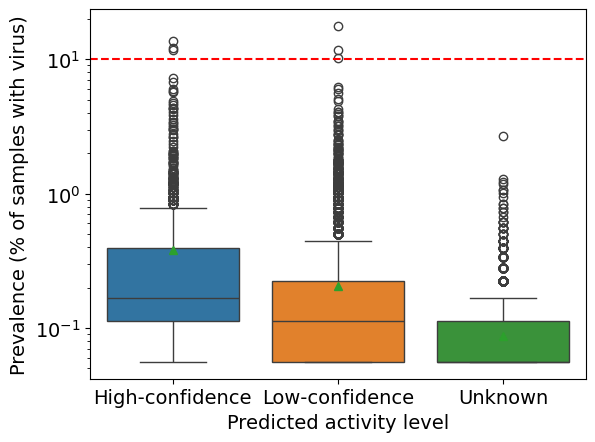

In [15]:
### scatterplot of prevalence vs activity score
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 14})

sns.boxplot(data=prevalence, x='activity_level', y='prevalence', showmeans=True, hue='activity_level')
plt.xlabel('Predicted activity level')
plt.ylabel('Prevalence (% of samples with virus)')
# draw horizontal line at 10%
plt.axhline(y=10, color='red', linestyle='--')
plt.yscale('log')
plt.show()

/tmp/ipykernel_84725/3543426840.py:11: DeprecationWarning: `DataFrame.melt` is deprecated; use `DataFrame.unpivot` instead, with `index` instead of `id_vars` and `on` instead of `value_vars`
  .melt(id_vars=['sample_id', 'bioproject', 'num_bp'], value_vars=['Unknown', 'Low-confidence', 'High-confidence'])
/tmp/ipykernel_84725/3543426840.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()


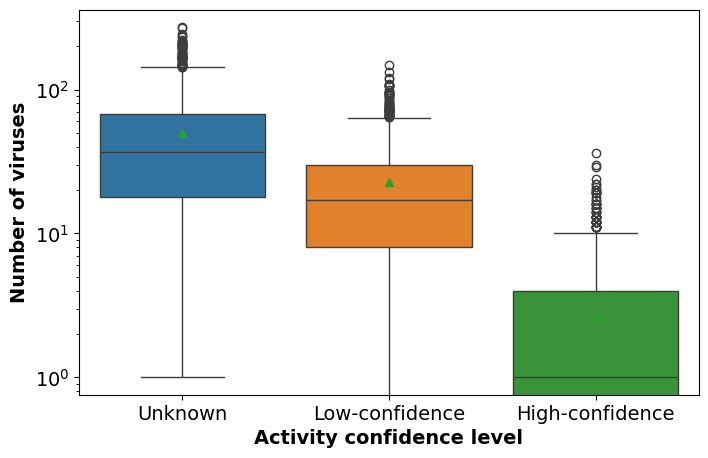

In [16]:
plot_df = (
    activity_data
        .group_by('sample_id')
        .agg([
            (pl.col('activity_score') >= 0).sum().alias('Unknown'),
            (pl.col('activity_score') >= 1).sum().alias('Low-confidence'),
            (pl.col('activity_score') >= 3).sum().alias('High-confidence'),
            pl.col('bioproject').first(),
            pl.col('num_bp').first()
        ])
        .melt(id_vars=['sample_id', 'bioproject', 'num_bp'], value_vars=['Unknown', 'Low-confidence', 'High-confidence'])
)

import seaborn as sns
import matplotlib.pyplot as plt

# make figure wide
plt.figure(figsize=(8,5))

sns.boxplot(data=plot_df.filter((pl.col('num_bp') <= pl.quantile('num_bp', 0.99)) & (pl.col('num_bp') >= 1e8)), x='variable', y='value', hue='variable', showmeans=True)
plt.yscale('log')
# hide legend
plt.xlabel('Activity confidence level', fontdict={'fontweight': 'bold'})
plt.ylabel('Number of viruses', fontdict={'fontweight': 'bold'})
plt.legend().remove()
plt.show()

In [24]:
plot_df.filter(pl.col('num_bp') >= 1e9).filter(pl.col('variable') == 'High-confidence')['value'].mean()

5.390022675736962

In [23]:
5e9/200

25000000.0

In [ ]:
plot_df.rename({"variable":"Activity Level"})

sample_id,bioproject,num_bp,Activity Level,value
str,str,i64,str,u32
"""SAMEA114218645_ERR11779026_cf""","""prjeb56242""",247829120,"""Unknown""",1
"""SAMN40993945_SRR28721150_cf""","""prjna1101448""",74390980,"""Unknown""",13
"""SAMEA4888915_ERR2785464_cf""","""prjeb28553""",20056891,"""Unknown""",2
"""SAMN33100532_SRR23346175_cf""","""prjna931830""",1064311774,"""Unknown""",85
"""SAMN28902366_SRR19579671_cf""","""prjna846291""",352885174,"""Unknown""",100
…,…,…,…,…
"""SAMN11310364_SRR8834190_cf""","""prjna530252""",1715472910,"""High-confidence""",1
"""SAMN40993828_SRR28721173_cf""","""prjna1101448""",83632164,"""High-confidence""",0
"""SAMN40993752_SRR28721256_cf""","""prjna1101448""",1369965356,"""High-confidence""",1


/gscratch/pedslabs_hoffman/carsonjm/micromamba_envs/envs/lgonsa/lib/python3.12/site-packages/seaborn/regression.py:598: UserWarning: sharey is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


<Figure size 800x600 with 0 Axes>

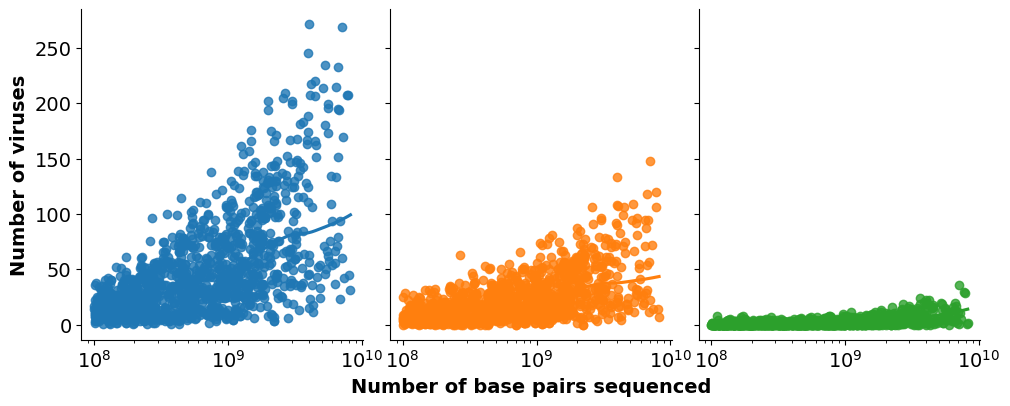

In [ ]:
# make figure wide
plt.figure(figsize=(8,6))

g = sns.lmplot(
    data=plot_df.rename({"variable":"Activity level"}).filter(
        (pl.col('num_bp') <= pl.quantile('num_bp', 0.99)) & (pl.col('num_bp') >= 1e8)
    ),
    x='num_bp',
    y='value',
    hue='Activity level',
    col='Activity level',
    lowess=True,
    sharey=True,
    height=4.5,
    aspect=0.75
)
g.set(xscale='log')
g.set_titles('')

# Keep only middle x-axis title and make axis titles bold
for ax in g.axes.flat:
    ax.set_xlabel('')
    ax.set_ylabel('')

mid_idx = len(g.axes.flat) // 2
g.axes.flat[mid_idx].set_xlabel('Number of base pairs sequenced', fontweight='bold', fontsize=14)
g.axes.flat[0].set_ylabel('Number of viruses', fontweight='bold', fontsize=14)

plt.show()

/tmp/ipykernel_66654/2851725301.py:24: DeprecationWarning: `DataFrame.melt` is deprecated; use `DataFrame.unpivot` instead, with `index` instead of `id_vars` and `on` instead of `value_vars`
  .melt(id_vars=['sample_id', 'bioproject', 'num_bp'], value_vars=['Unknown', 'Low-confidence', 'High-confidence'])


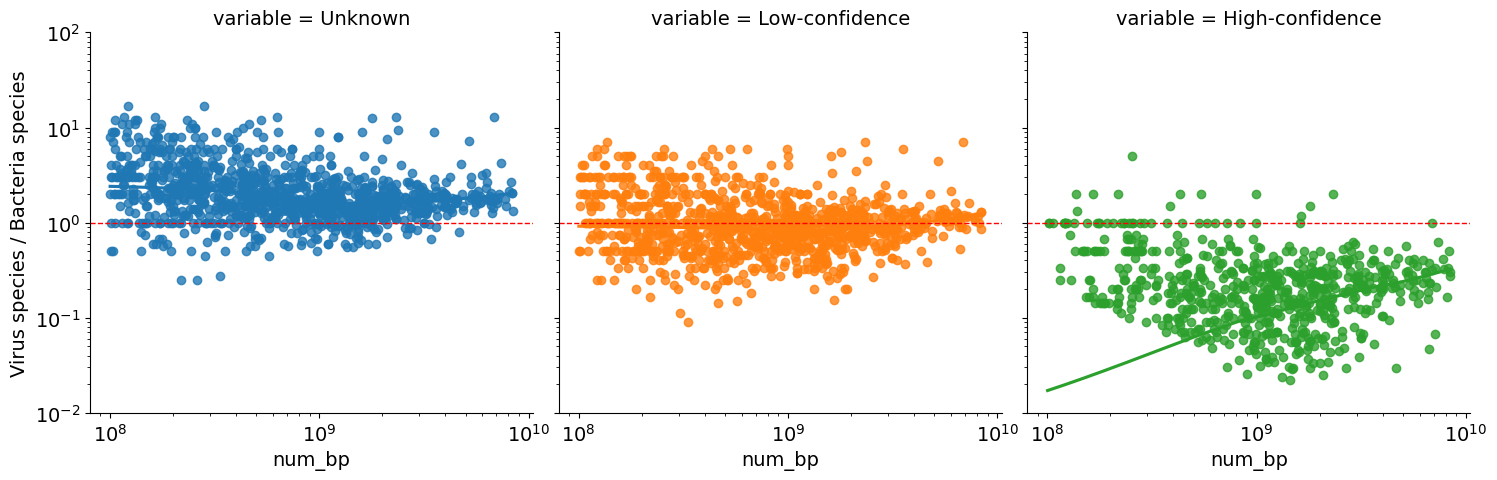

In [ ]:
bac_count = (
    sylph_df
        .filter((pl.col('True_cov') >= 4) & (pl.col('Genome_file').str.starts_with('R226CHUNK')))
        .group_by('sample_id')
        .agg([
            pl.col('num_bp').first(),
            pl.col('bioproject').first(),
            (pl.col('Genome_file').str.starts_with('R226CHUNK')).sum().alias('num_bac'),
        ])
        [['sample_id', 'num_bac']]
)

plot2_df = (
    activity_data
        .filter(pl.col('True_cov_virus') >= 4)
        .group_by('sample_id')
        .agg([
            (pl.col('activity_score') >= 0).sum().alias('Unknown'),
            (pl.col('activity_score') >= 1).sum().alias('Low-confidence'),
            (pl.col('activity_score') >= 3).sum().alias('High-confidence'),
            pl.col('bioproject').first(),
            pl.col('num_bp').first()
        ])
        .melt(id_vars=['sample_id', 'bioproject', 'num_bp'], value_vars=['Unknown', 'Low-confidence', 'High-confidence'])
        .join(bac_count, on='sample_id', how='full', coalesce=True)
        .with_columns([(pl.col('value') / (pl.col('num_bac'))).alias('Virus species / Bacteria species')])
)


import seaborn as sns
import matplotlib.pyplot as plt

# make figure wide
# plt.figure(figsize=(10,6))

g=sns.lmplot(data=plot2_df.filter((pl.col('num_bp') <= pl.quantile('num_bp', 0.99)) & (pl.col('num_bp') >= 1e8)), x='num_bp', y='Virus species / Bacteria species', hue='variable', col='variable', lowess=True)
g.set(xscale='log', yscale='log')
g.set(ylim=(0.01, 100))

for ax in g.axes.flat:
    ax.axhline(y=1, color='red', linestyle='--', linewidth=1)

plt.show()

In [ ]:
# identify cf pathogens
# !wget https://fileshare.lisc.univie.ac.at/globdb/globdb_r226/globdb_r226_taxonomy.tsv.gz

cf_pathogens = (
    pl.read_csv('globdb_r226_taxonomy.tsv.gz', separator='\t', has_header=False)
        .with_columns([
            pl.col('column_2').str.split(';').list[5].alias('genus'),
            pl.col('column_1').alias('genome_id')
        ])
        .filter(
            (pl.col('genus') == 'g__Pseudomonas') |
            (pl.col('genus') == 'g__Staphylococcus') |
            (pl.col('genus') == 'g__Burkholderia') |
            (pl.col('genus') == 'g__Haemophilus') |
            (pl.col('genus') == 'g__Achromobacter') |
            (pl.col('genus') == 'g__Stenotrophomonas') |
            (pl.col('genus') == 'g__Mycobacterium')
        )
        .with_columns([
            pl.col('genus').str.replace('g__', '')
        ])
        [['genus', 'genome_id']]
)

cf_pathogens_sylph = (
    sylph_df
        .with_columns([
            pl.col('Genome_file').str.split('/').list[-1].str.split('.').list[0].alias('genome_id')
        ])
        .join(cf_pathogens, on='genome_id', how='inner', coalesce=True)
        [['sample_id', 'genome_id', 'genus', 'True_cov', 'Sequence_abundance']]
)

activity_cf_pathogens = (
    activity_data
        .join(cf_pathogens_sylph.filter(pl.col('Sequence_abundance') >= 50), on='sample_id', how='inner', coalesce=True)
        .with_columns([
            (pl.col('True_cov_virus') / pl.col('True_cov')).alias('virus_to_bac_cov_ratio')
        ])
)

/tmp/ipykernel_66654/3282694073.py:4: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(data=cf_pathogens_sylph, x='genus', y='Sequence_abundance', hue='genus', dodge=True, color='black', alpha=0.5, size=3)


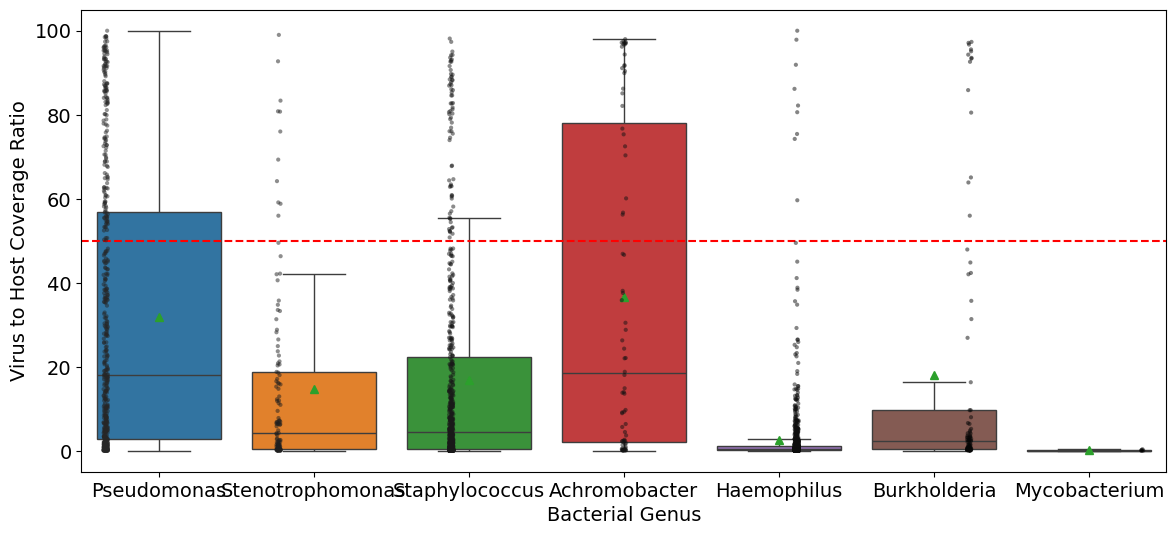

In [ ]:
plt.figure(figsize=(14,6))
sns.boxplot(data=cf_pathogens_sylph, x='genus', y='Sequence_abundance', hue='genus', showmeans=True, showfliers=False)
# plot all points
sns.stripplot(data=cf_pathogens_sylph, x='genus', y='Sequence_abundance', hue='genus', dodge=True, color='black', alpha=0.5, size=3)
plt.xlabel('Bacterial Genus')
plt.ylabel('Virus to Host Coverage Ratio')
# add horizontal line at y=2
plt.axhline(y=50, color='red', linestyle='--')
plt.show()

In [ ]:
cf_pathogens_sylph.filter(pl.col('Sequence_abundance') > 50).group_by('genus').len()

genus,len
str,u32
"""Stenotrophomonas""",11
"""Staphylococcus""",73
"""Achromobacter""",26
"""Burkholderia""",14
"""Haemophilus""",9
"""Pseudomonas""",159


<Axes: xlabel='virus_to_host', ylabel='Count'>

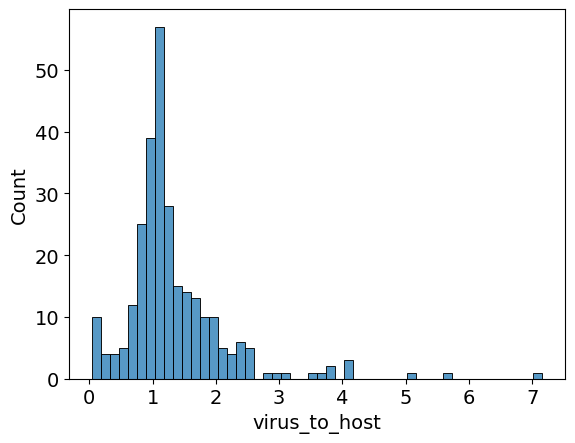

In [ ]:
### create virus to host ratio for cf pathogen samples
cf_virus_activity = (
    activity_cf_pathogens
    .filter((pl.col('breadth_ratio') >= 0.6))
    .sort('trimmed_mean', descending=True)
    .unique(['sample_id', 'genome_id', 'genus', 'True_cov'])
    .with_columns((pl.col('True_cov_virus')/pl.col('True_cov')).alias('virus_to_host'))
    .with_columns(
        pl.when(pl.col('activity_score') >= 3).then(pl.lit('hc active'))
            .when(pl.col('activity_score') >= 1).then(pl.lit('lc active'))
            .otherwise(pl.lit('activity unknown'))
            .alias('activity_status'),
        pl.when(pl.col('virus_to_host') >= 2).then(pl.lit('cov active'))
            .otherwise(pl.lit('cov unknown'))
            .alias('ratio_cat')
    )
)

sns.histplot(cf_virus_activity.filter(pl.col('virus_to_host') < 10), x='virus_to_host', bins=50)

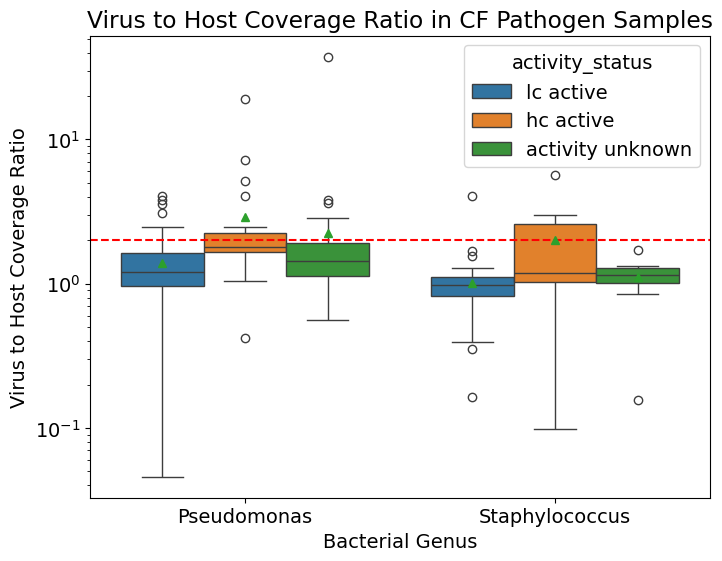

In [ ]:


### create boxplot of virus to host ratio
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.boxplot(data=cf_virus_activity.filter(pl.col('genus').is_in(['Staphylococcus', 'Pseudomonas'])), x='genus', y='virus_to_host', hue='activity_status', showmeans=True, showfliers=True)
# plot all points
plt.yscale('log')
plt.xlabel('Bacterial Genus')
plt.ylabel('Virus to Host Coverage Ratio')
plt.title('Virus to Host Coverage Ratio in CF Pathogen Samples')
# add horizontal line at y=2
plt.axhline(y=2, color='red', linestyle='--')
plt.show()

In [ ]:
cf_virus_activity.group_by('genus').len()

genus,len
str,u32
"""Stenotrophomonas""",10
"""Pseudomonas""",153
"""Haemophilus""",5
"""Staphylococcus""",73
"""Achromobacter""",26
"""Burkholderia""",14


In [ ]:
cf_virus_activity

contig_id,sample_id,bioproject,num_bp,breadth_score,ref_dtr_score,ref_virulent_score,trimmed_mean,mean,breadth,breadth_ratio,True_cov_virus,completeness_method,virulent,dtr_score,num_oprs,num_clipped,CohenD,prophage-host_ratio,mvirs_score,propagate_score,activity_score,reference_activity_score,genome_id,genus,True_cov,Sequence_abundance,virus_to_host,activity_status,ratio_cat
str,str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,str,str,f64,f64,f64,f64,f64,f64,str,str,f64,f64,f64,str,str
"""SAMEA10741592_k141_200378""","""SAMEA5554287_ERR3274621_cf""","""prjeb32062""",2113409142,1.0,0.0,0.0,12.864998,13.050189,0.942236,0.942254,14.846,"""AAI-based (high-confidence)""",0.0,0.0,null,null,null,null,0.0,0.0,1.0,1.0,"""GCF_001457615""","""Pseudomonas""",252.384,81.1054,0.058823,"""lc active""","""cov unknown"""
"""SAMN33100415_SRR23346119_cf_k2…","""SAMN33100656_SRR23346206_cf""","""prjna931830""",6441599120,1.0,0.0,0.0,4196.09,4067.3628,1.0,1.0,2994.307,"""AAI-based (high-confidence)""",0.0,0.0,"""808""","""84""",null,null,3.0,0.0,4.0,1.0,"""GCF_001457615""","""Pseudomonas""",418.148,56.8903,7.160878,"""hc active""","""cov active"""
"""SAMN40150511.contig00038""","""SAMEA110233630_ERR9901974_cf""","""prjeb54014""",258486120,0.0,0.0,0.0,37.024494,37.883514,0.669343,0.669343,60.02,"""ITR (high-confidence)""",0.83418,0.0,"""18""","""33""",3.724417,2.331487,3.0,3.0,6.0,0.0,"""GCF_001457615""","""Pseudomonas""",27.152,83.9325,2.210519,"""hc active""","""cov active"""
"""SAMEA5578835.contig00031|provi…","""SAMEA14381344_ERR10814762_cf""","""prjeb52317""",51824016,1.0,0.0,0.0,5.993206,6.065857,0.978616,0.98491,8.992,"""AAI-based (high-confidence)""",0.0,0.0,null,null,null,null,0.0,0.0,1.0,1.0,"""GCF_001457615""","""Pseudomonas""",4.638,61.532,1.938767,"""lc active""","""cov unknown"""
"""SRR8731627_156""","""SAMN11135472_SRR8731627_cf""","""prjna516442""",431654622,1.0,0.0,0.0,68.12003,68.4772,1.0,1.0,67.865,"""AAI-based (high-confidence)""",0.0,0.0,"""1""","""4""",0.452638,1.13237,3.0,0.0,4.0,1.0,"""GCF_001457615""","""Pseudomonas""",59.974,92.1199,1.131574,"""hc active""","""cov unknown"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""SAMEA3924226.contig00002|provi…","""SAMN27562284_SRR19051644_cf""","""prjna825831""",847934906,0.0,0.0,0.0,174.14514,178.14207,0.78405,0.78405,257.046,"""AAI-based (high-confidence)""",0.0,0.0,null,null,1.253995,1.730027,0.0,1.0,1.0,0.0,"""GCF_001027105""","""Staphylococcus""",151.282,56.4531,1.699118,"""lc active""","""cov unknown"""
"""SAMEA104128203.contig00044""","""SAMN11135523_SRR8731657_cf""","""prjna516442""",64099209,0.0,0.0,0.0,11.119626,11.540638,0.647635,0.647678,18.002,"""AAI-based (high-confidence)""",0.832544,0.0,"""37""","""1""",null,null,3.0,0.0,3.0,0.0,"""GCF_001457615""","""Pseudomonas""",8.697,90.6648,2.069909,"""hc active""","""cov active"""
"""SAMN47007015.contig00001|provi…","""SAMEA4888939_ERR2785487_cf""","""prjeb28553""",185170748,1.0,0.0,0.0,19.029509,20.230326,0.952316,0.952316,21.519,"""AAI-based (high-confidence)""",0.0,0.0,null,null,null,null,0.0,0.0,1.0,1.0,"""GCF_001457615""","""Pseudomonas""",13.511,50.6404,1.592702,"""lc active""","""cov unknown"""


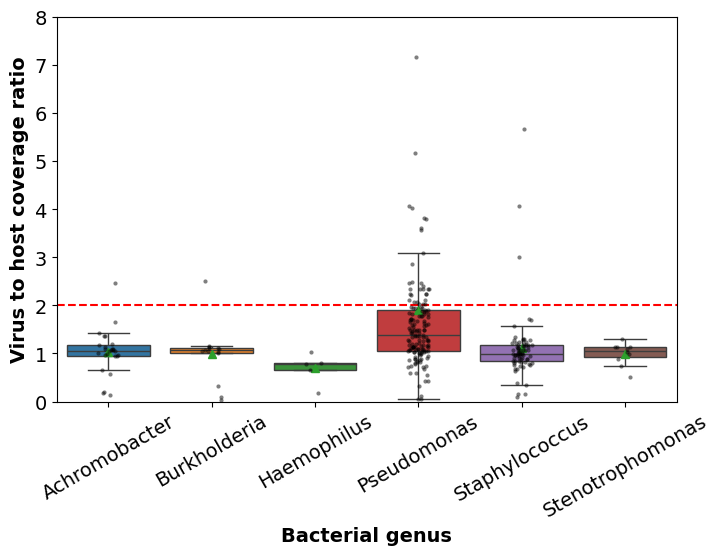

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=cf_virus_activity.sort('genus'), x='genus', y='virus_to_host', hue='genus', showfliers=False, showmeans=True)
# plot all points sort genera alphabetically
sns.stripplot(data=cf_virus_activity.sort('genus'), x='genus', y='virus_to_host', color='black', alpha=0.5, size=3)
# plt.yscale('log')
plt.xlabel('Bacterial genus', fontdict={'fontweight': 'bold'})
plt.ylabel('Virus to host coverage ratio', fontdict={'fontweight': 'bold'})
# add horizontal line at y=2
plt.axhline(y=2, color='red', linestyle='--')
# rotate x labels
plt.xticks(rotation=30)
plt.ylim(0,8)
plt.show()

In [ ]:
cf_virus_activity.filter(pl.col('genus') == 'Pseudomonas')['virus_to_host'].describe()

statistic,value
str,f64
"""count""",153.0
"""null_count""",0.0
"""mean""",1.913262
"""std""",3.335057
"""min""",0.045983
"""25%""",1.049184
"""50%""",1.391307
"""75%""",1.907702
"""max""",37.418153


In [ ]:
# cf_virus_activity.filter(pl.col('virus_to_host') >= 2).write_csv('cf_pathogen_cov_active.tsv', separator='\t')